# NN Win Probability — Model Interpretability

Using **Captum** (PyTorch's interpretability library) to understand what the NN has learned.

Three angles:
1. **Integrated Gradients** — how much does each feature contribute to a specific prediction?
2. **Feature sensitivity** — how does win_prob change as we vary one feature while holding others fixed?
3. **2D heatmaps** — win_prob surface across `(runs_needed, balls_remaining)` at fixed wickets

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pickle
from pathlib import Path

from captum.attr import IntegratedGradients, FeatureAblation

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

MODELS_DIR = Path('../models')
FIG_DIR = Path('../data/figures/04_model_interpretability')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load model

In [2]:
class WinProbNet(nn.Module):
    def __init__(self, input_dim=6, hidden_dims=[64, 32, 16]):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(0.1)]
            prev = h
        layers += [nn.Linear(prev, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


ckpt = torch.load(MODELS_DIR / 'win_prob_nn.pt', weights_only=False)
model = WinProbNet(input_dim=ckpt['input_dim'], hidden_dims=ckpt['hidden_dims'])
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

FEATURE_COLS = ckpt['feature_cols']
X_mean = ckpt['X_mean']
X_std  = ckpt['X_std']

with open(MODELS_DIR / 'emp_lookup.pkl', 'rb') as f:
    emp_lookup = pickle.load(f)

print('Model loaded. Features:', FEATURE_COLS)


def make_input(runs_needed, balls_remaining, wickets_fallen):
    """Build a normalised input tensor from raw state values."""
    rrr = runs_needed / (balls_remaining + 1)
    bf  = balls_remaining / 120
    wf  = wickets_fallen / 10
    raw = np.array([[runs_needed, balls_remaining, wickets_fallen, rrr, bf, wf]], dtype=np.float32)
    return torch.tensor((raw - X_mean) / X_std)


def predict(runs_needed, balls_remaining, wickets_fallen):
    with torch.no_grad():
        return model(make_input(runs_needed, balls_remaining, wickets_fallen)).item()

Model loaded. Features: ['runs_needed', 'balls_remaining', 'wickets_fallen', 'rrr', 'balls_fraction', 'wickets_fraction']


## Part 1: Integrated Gradients — per-ball feature attribution on DC vs GT

For each ball in the chase, IG tells us how much each feature *pushed* the prediction up or down relative to a baseline (all-zeros = match start).

In [3]:
import json

def parse_chase(path):
    d = json.load(open(path))
    inn1, inn2 = d['innings'][0], d['innings'][1]
    target = sum(b['runs']['total'] for ov in inn1['overs'] for b in ov['deliveries']) + 1
    total_balls = sum(
        1 for ov in inn1['overs'] for b in ov['deliveries']
        if 'wides' not in b.get('extras', {}) and 'noballs' not in b.get('extras', {})
    )
    rows, score, wickets, legal_ball = [], 0, 0, 0
    for ov in inn2['overs']:
        for b in ov['deliveries']:
            ext = list(b.get('extras', {}).keys())
            is_legal = 'wides' not in ext and 'noballs' not in ext
            score += b['runs']['total']
            if 'wickets' in b:
                wickets += len(b['wickets'])
            if is_legal:
                legal_ball += 1
                rn = target - score
                br = total_balls - legal_ball
                rows.append({
                    'legal_ball': legal_ball, 'runs_needed': rn,
                    'balls_remaining': br, 'wickets_fallen': wickets,
                    'is_wicket': 'wickets' in b,
                })
    return pd.DataFrame(rows), target


chase_dcgt, target_dcgt = parse_chase('../data/raw/dc_vs_gt_2026-04-08.json')
print(f'DC vs GT — target: {target_dcgt}, balls: {len(chase_dcgt)}')

DC vs GT — target: 211, balls: 120


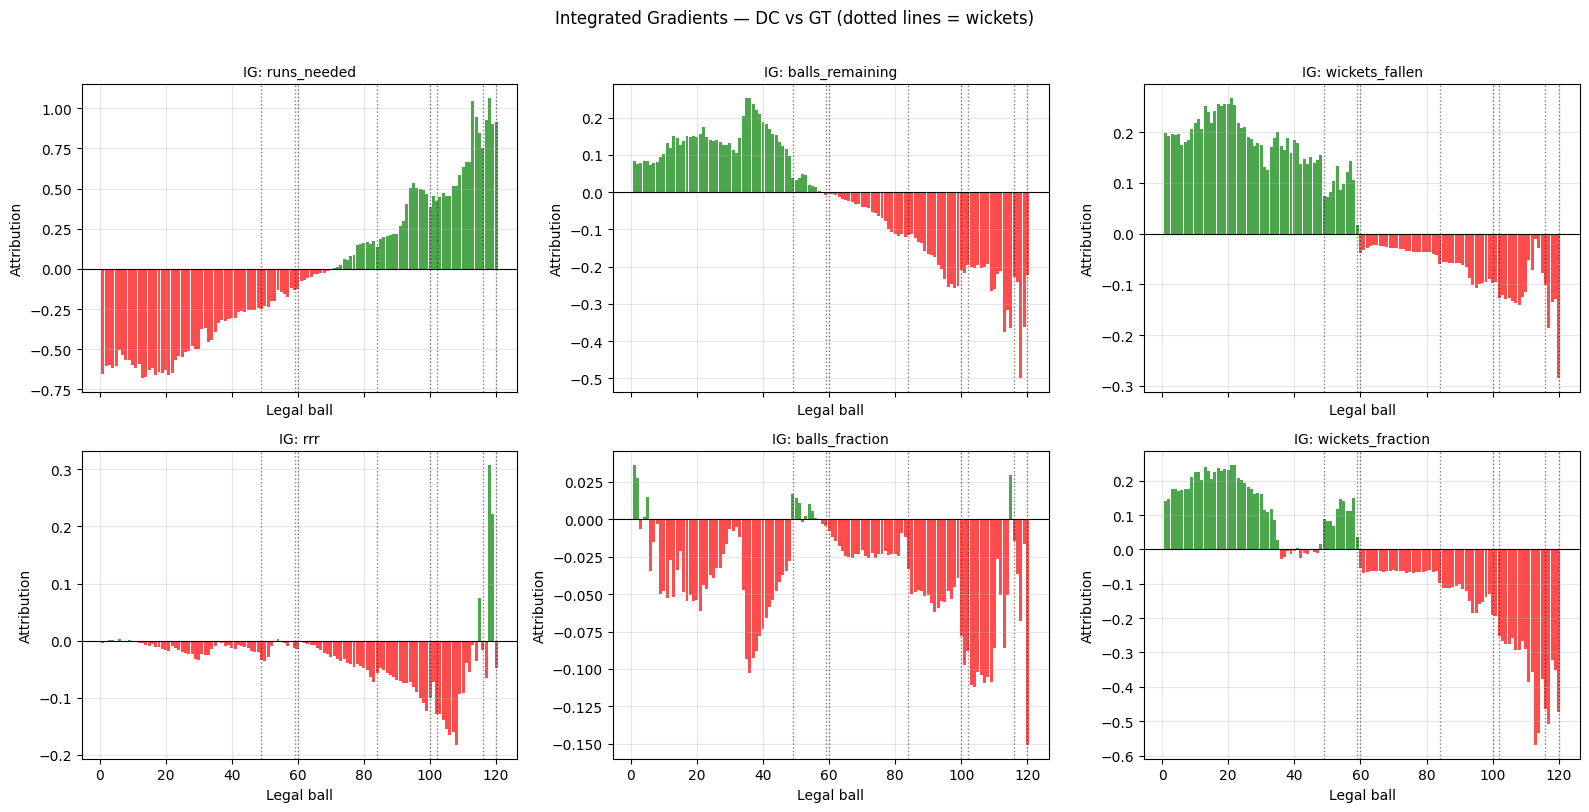


Mean |attribution| per feature (DC vs GT):
runs_needed         0.3884
wickets_fraction    0.1544
balls_remaining     0.1384
wickets_fallen      0.1225
balls_fraction      0.0416
rrr                 0.0408
dtype: float32


In [4]:
ig = IntegratedGradients(model)
baseline = torch.zeros(1, len(FEATURE_COLS))  # baseline: all-zero (normalised)

# Build input tensor for the full chase
def chase_to_tensor(df):
    df = df.copy()
    df['rrr']             = df['runs_needed'] / (df['balls_remaining'] + 1)
    df['balls_fraction']  = df['balls_remaining'] / 120
    df['wickets_fraction']= df['wickets_fallen'] / 10
    raw = df[FEATURE_COLS].values.astype(np.float32)
    return torch.tensor((raw - X_mean) / X_std)

X_dcgt = chase_to_tensor(chase_dcgt)
attrs = ig.attribute(X_dcgt, baselines=baseline.expand(len(X_dcgt), -1), n_steps=50)
attrs_np = attrs.detach().numpy()  # shape: (n_balls, n_features)

# Plot attributions per feature over the chase
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.flatten()
balls = chase_dcgt['legal_ball'].values
wicket_balls = chase_dcgt[chase_dcgt['is_wicket']]['legal_ball'].values

for i, (ax, feat) in enumerate(zip(axes, FEATURE_COLS)):
    ax.bar(balls, attrs_np[:, i],
           color=['green' if v >= 0 else 'red' for v in attrs_np[:, i]],
           alpha=0.7, width=0.9)
    for wb in wicket_balls:
        ax.axvline(wb, color='black', linewidth=1, linestyle=':', alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'IG: {feat}', fontsize=10)
    ax.set_xlabel('Legal ball')
    ax.set_ylabel('Attribution')

plt.suptitle('Integrated Gradients — DC vs GT (dotted lines = wickets)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ig_dcgt.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary: mean absolute attribution per feature
mean_abs = np.abs(attrs_np).mean(axis=0)
importance = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False)
print('\nMean |attribution| per feature (DC vs GT):')
print(importance.round(4))

## Part 2: Feature Sensitivity — how does win_prob respond to each variable?

Hold two features fixed, sweep the third across its realistic range. Gives us the model's learned response curves.

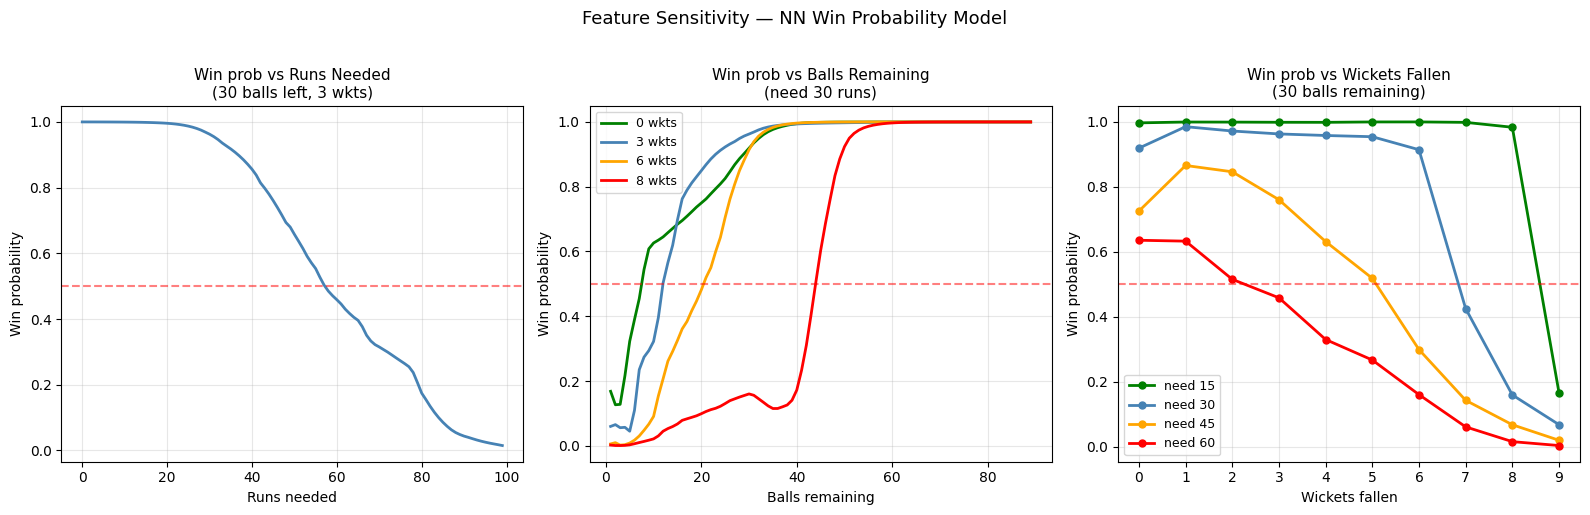

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Win prob vs runs_needed (fix: 30 balls left, 3 wickets)
rn_range = np.arange(0, 100)
probs = [predict(rn, 30, 3) for rn in rn_range]
axes[0].plot(rn_range, probs, color='steelblue', linewidth=2)
axes[0].set_title('Win prob vs Runs Needed\n(30 balls left, 3 wkts)', fontsize=11)
axes[0].set_xlabel('Runs needed')
axes[0].set_ylabel('Win probability')
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5)

# 2. Win prob vs balls_remaining (fix: need 30, 3 wickets)
br_range = np.arange(1, 90)
for wk, col, lbl in [(0, 'green', '0 wkts'), (3, 'steelblue', '3 wkts'),
                      (6, 'orange', '6 wkts'), (8, 'red', '8 wkts')]:
    probs = [predict(30, br, wk) for br in br_range]
    axes[1].plot(br_range, probs, color=col, linewidth=2, label=lbl)
axes[1].set_title('Win prob vs Balls Remaining\n(need 30 runs)', fontsize=11)
axes[1].set_xlabel('Balls remaining')
axes[1].set_ylabel('Win probability')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].legend(fontsize=9)

# 3. Win prob vs wickets_fallen (fix: need 30, 30 balls left)
wk_range = np.arange(0, 10)
for rn, col, lbl in [(15, 'green', 'need 15'), (30, 'steelblue', 'need 30'),
                      (45, 'orange', 'need 45'), (60, 'red', 'need 60')]:
    probs = [predict(rn, 30, wk) for wk in wk_range]
    axes[2].plot(wk_range, probs, color=col, linewidth=2, marker='o', markersize=5, label=lbl)
axes[2].set_title('Win prob vs Wickets Fallen\n(30 balls remaining)', fontsize=11)
axes[2].set_xlabel('Wickets fallen')
axes[2].set_ylabel('Win probability')
axes[2].axhline(0.5, color='red', linestyle='--', alpha=0.5)
axes[2].legend(fontsize=9)
axes[2].set_xticks(range(10))

plt.suptitle('Feature Sensitivity — NN Win Probability Model', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 3: 2D Heatmaps — win_prob surface

Win probability across `(runs_needed, balls_remaining)` at different wicket counts. Lets us see the decision boundary the NN has learned.

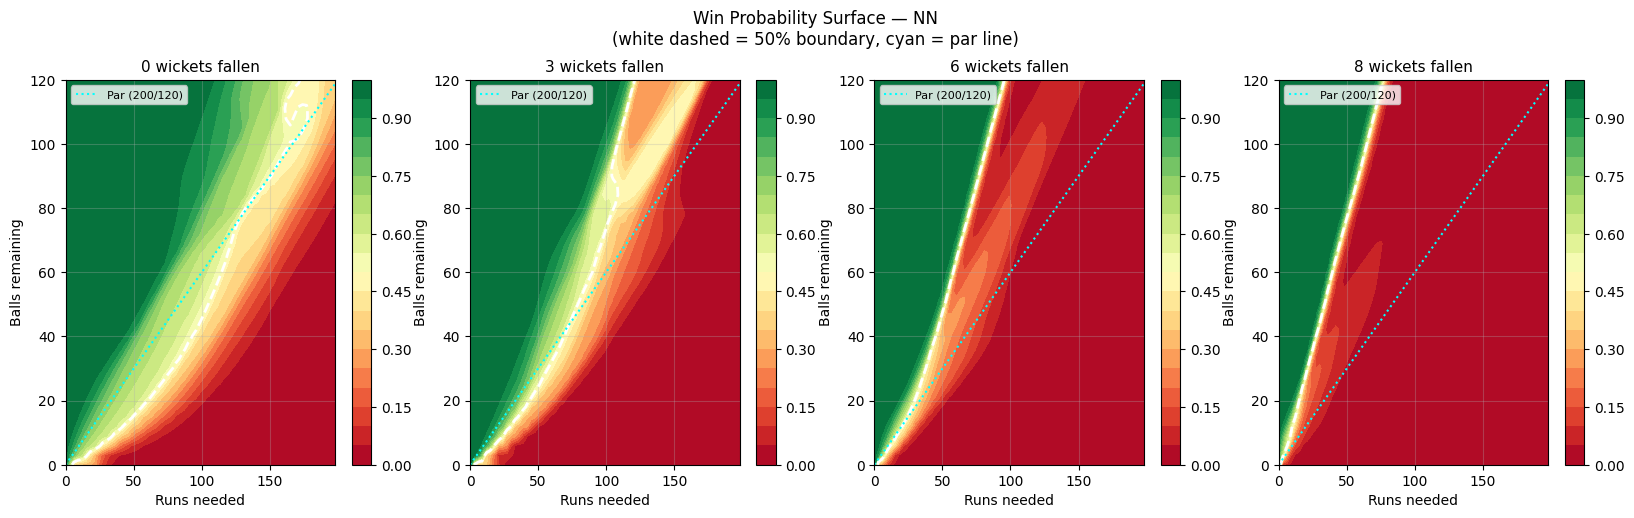

In [6]:
# Note: the cyan "par" line (200/120) pushes the x-axis out to ~200.
# If we only compute rn_vals up to 120, the right half of the panel has no data and looks blank.
rn_vals = np.arange(0, 201, 3)
br_vals = np.arange(0, 121, 3)
RN, BR  = np.meshgrid(rn_vals, br_vals)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, wk in zip(axes, [0, 3, 6, 8]):
    Z = np.zeros_like(RN, dtype=float)
    for i in range(RN.shape[0]):
        for j in range(RN.shape[1]):
            Z[i, j] = predict(RN[i, j], BR[i, j], wk)

    im = ax.contourf(RN, BR, Z, levels=20, cmap='RdYlGn', vmin=0, vmax=1)
    ax.contour(RN, BR, Z, levels=[0.5], colors='white', linewidths=2, linestyles='--')
    plt.colorbar(im, ax=ax)

    # Add the 50% line label
    ax.set_title(f'{wk} wickets fallen', fontsize=11)
    ax.set_xlabel('Runs needed')
    ax.set_ylabel('Balls remaining')

    # Mark the "par" line: runs_needed = balls_remaining * 1.667
    par_rn = br_vals * 1.667
    ax.plot(par_rn, br_vals, color='cyan', linewidth=1.5, linestyle=':', label='Par (200/120)')

    # Keep axes consistent across panels
    ax.set_xlim(rn_vals.min(), rn_vals.max())
    ax.set_ylim(br_vals.min(), br_vals.max())
    ax.legend(fontsize=8)

plt.suptitle('Win Probability Surface — NN\n(white dashed = 50% boundary, cyan = par line)', fontsize=12, y=1.02)
plt.savefig(FIG_DIR / 'heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 4: Feature Ablation — global feature importance

Remove one feature at a time (replace with its mean) and measure the drop in accuracy. Shows which features the model actually relies on.

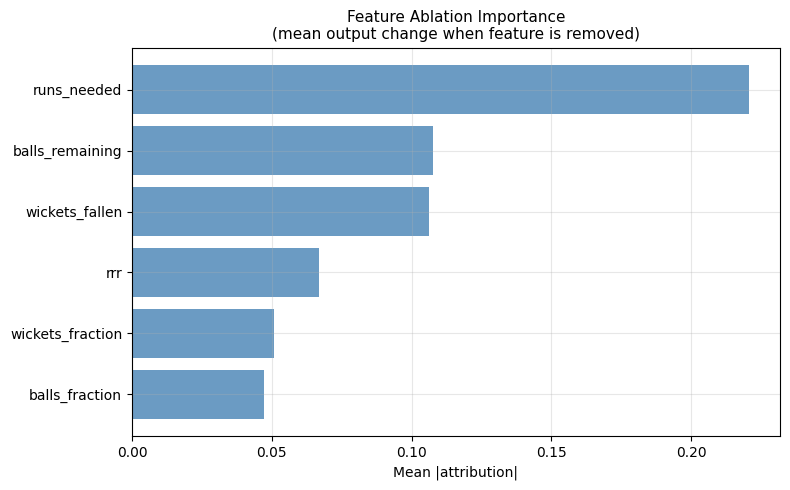

         feature  importance
     runs_needed    0.220704
 balls_remaining    0.107602
  wickets_fallen    0.106171
             rrr    0.066915
wickets_fraction    0.050954
  balls_fraction    0.047256


In [8]:
# Build a small representative test set from our 4 matches
match_files = [
    '../data/raw/dc_vs_gt_2026-04-08.json',
    '../data/raw/ind_vs_pak_2024-06-09.json',
    '../data/raw/rr_vs_mi_2026-04-07.json',
    '../data/raw/mi_vs_rr_2025-05-01.json',
]

all_chase = []
for path in match_files:
    df, _ = parse_chase(path)
    all_chase.append(df)
test_df = pd.concat(all_chase, ignore_index=True)

# Guardrails: some matches have <120 legal balls in innings 1 (all out).
# If we compute balls_remaining from innings-1 legal balls, innings-2 can exceed it -> balls_remaining becomes negative,
# rrr divides by (balls_remaining + 1) and can produce inf -> downstream NaNs.
# For interpretability plots we only keep valid T20 chase states.
test_df = test_df[(test_df['balls_remaining'] >= 0) & (test_df['balls_remaining'] <= 120)].copy()
test_df['runs_needed'] = test_df['runs_needed'].clip(lower=0)

X_test = chase_to_tensor(test_df)
X_test = torch.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

fa = FeatureAblation(model)
mask = torch.arange(len(FEATURE_COLS), dtype=torch.long).view(1, -1).expand_as(X_test)

# In normalised space, 0 ~= mean feature value
ablation_attrs = fa.attribute(X_test, feature_mask=mask, baselines=0.0)

mean_ablation = ablation_attrs.abs().mean(dim=0).detach().cpu().numpy()
importance_df = (
    pd.DataFrame({'feature': FEATURE_COLS, 'importance': mean_ablation})
    .sort_values('importance', ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue', alpha=0.8)
ax.set_title('Feature Ablation Importance\n(mean output change when feature is removed)', fontsize=11)
ax.set_xlabel('Mean |attribution|')
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance_df.sort_values('importance', ascending=False).to_string(index=False))